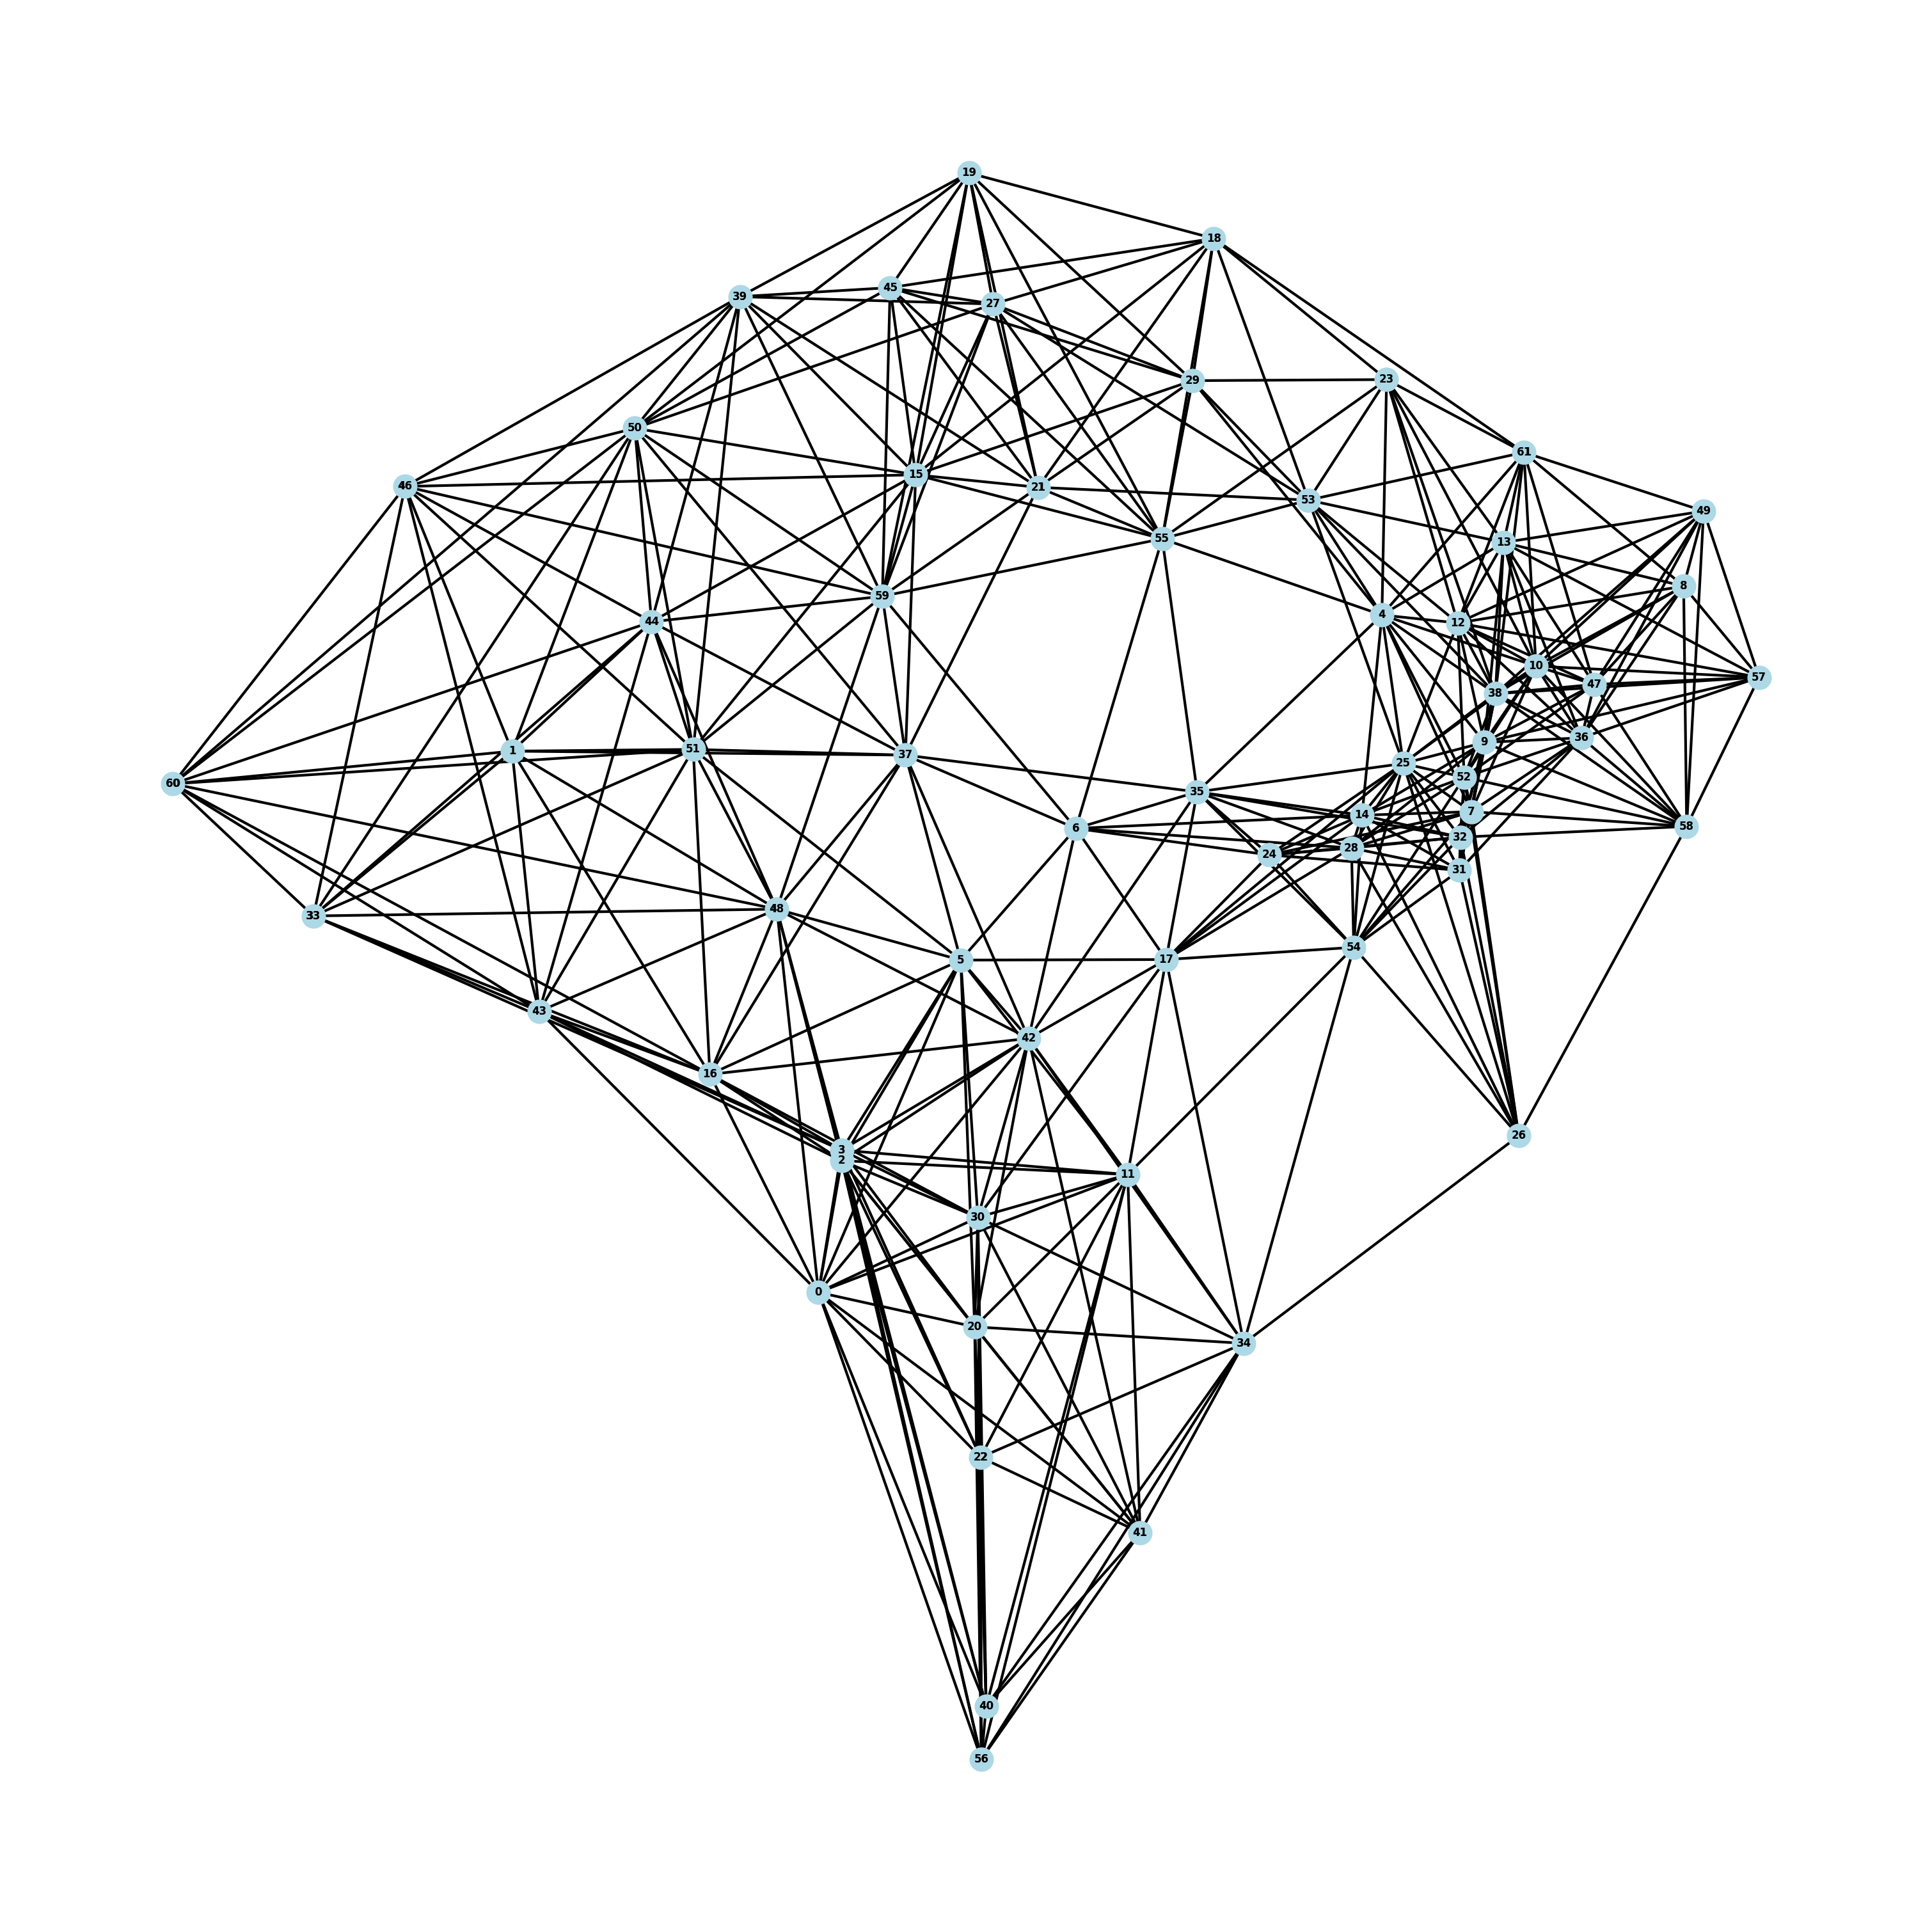

In [12]:
import torch
import sys
import itertools
import os
import copy
import json
import time
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr

from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sys.path.append("../src")
from pathlib import Path
from Models.model import GLSTM_v2
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore,
                                add_consecutive_dry_days_feature)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss, make_weighted_mse_loss_standardized
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import train_stable


device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

RUN_MODE        = "full"                 # quick or full
if RUN_MODE     == "full":
    start_date  = "2000-01-01"
    end_date    = "2025-12-31"

elif RUN_MODE   == "custom":
    start_date  = "2010-01-01"
    end_date    = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"

T            = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1

eps          = 1e-6
window_size  = 30
horizon      = 1
criterion_km = 120
lstm_layers  = 1
dropout      = 0.2
K            = 10
batch_size   = 256
num_workers  = 4
vertex_idx   = 32
weight_decay = 5e-4
T_max        = 50
test_lstm    = False
learn_adj    = True
criterion    = nn.HuberLoss(delta=5)
topology     = 'knn'  # 'knn' ou 'distance'

log_norm     = False 
z_score      = True


catalog_dir = Path(os.path.join("..", "Datasets", "dados_inmet"))
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos               = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)
    
    
    
plot_graph(N,edge_index, pos=pos)

In [2]:
# Carregamento dos arquivos NetCDF (Datasets)
dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
#rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
#rea_wind = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_wind_14-25.nc")).sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
#vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
#print("Done loading vv in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
temp_daily_dataset = daily_temp_features(rea_temp)
print("Done loading temp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))
print("Done loading tp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
#wind_daily = daily_wind_uv_features(rea_wind)
#print("Done loading wind in memory"+"\nTime taken: {:.2f} seconds".format(time.time()-dataset_load_time))

print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

Done loading datasets in memory
Time taken: 1.76 seconds
Done loading temp in memory
Time taken: 13.02 seconds
Done loading tp in memory
Time taken: 23.51 seconds
Dataset com 9497 dias disponíveis.


# Extração do dataset do ERA-5





Input features
 - Daily precipitation
 - vertical velocity of wind
 - Temperature and dewpoint
 - u-v components of wind

The tensor $X$ has shape $[days, nodes, features]$, with all dataset available, with the $X$ we construct the time windows $X_s$ (inputs) and $y_s$ (targets)



In [3]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)

#X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")


#X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
#                           estacoes_RS,
#                           start=start_date,
#                           end=end_date,
#                           u_var="u",
#                           v_var="v"
#                           ).reshape(X_tp.shape[0], X_tp.shape[1], -1)

# Creating temporal dataset

The tensor X is transformed in two new tensors, $X_s$ and $y_s$ (inputs and targets), such that: 

 - $X_s$: $[B, W_{in}, N, F]$;
 - $y_s$: $[B, W_{out}, N]$;
 - $B$ : number of time windows created, with $W_{in}$ days of feed to forecast the next $W_{out}$ days;
 - $N$  : number of nodes (stations)
 - $F$  : number of input features by node



In [17]:
#CRIAÇÃO DE JANELAS DE TEMPO

# Escolha das features para alimentar o modelo
#X = torch.cat([X_tp, X_temp[:,:,2].unsqueeze(-1), X_sh[:,:,3].unsqueeze(-1)], dim=-1)
X = X_tp
if log_norm:
    X[...,0] = torch.log1p(X[...,0])


#X = add_consecutive_dry_days_feature(
#    X, 
#    precip_col=0,
#    dry_threshold=2
#)


print(X.shape)



print("Janela de entrada: "+str(window_size)+" dias, horizonte de previsão: "+str(horizon)+" dias")
X_train, y_train, X_val, y_val, X_test, y_test = temporal_train_val_test_split(X, X[...,0], window_size=window_size, horizon=horizon)


# Cria janelas de treino, validação e teste
# = train_split(Xs, ys)

if z_score:
    scaler_tp = StandardScaler()
    scaler_tp.fit(X_train[...,0].reshape(-1,1))
    X_train[...,0]  = torch.tensor(scaler_tp.transform(X_train[...,0].reshape(-1,1)), dtype=torch.float32).reshape(X_train[...,0].shape)
    y_train         = torch.tensor(scaler_tp.transform(y_train.reshape(-1,1)), dtype=torch.float32).reshape(y_train.shape)
    X_val[...,0]    = torch.tensor(scaler_tp.transform(X_val[...,0].reshape(-1,1)  ), dtype=torch.float32).reshape(X_val[...,0].shape)
    y_val           = torch.tensor(scaler_tp.transform(y_val.reshape(-1,1)), dtype=torch.float32).reshape(y_val.shape)
    X_test[...,0]   = torch.tensor(scaler_tp.transform(X_test[...,0].reshape(-1,1)  ), dtype=torch.float32).reshape(X_test[...,0].shape)


# padroniza apenas features exogenas (colunas 2:)
X_train[..., 1:], scalers = normalize_features(X_train[..., 1:], scaler=MinMaxScaler)

for i, sc in enumerate(scalers):
    X_val[..., 1 + i] = torch.tensor(
        sc.transform(X_val[..., 1 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 1 + i].shape)
    X_test[..., 1 + i] = torch.tensor(
        sc.transform(X_test[..., 1 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 1 + i].shape)

# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers, persistent_workers=True, prefetch_factor=4)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

torch.Size([9497, 62, 1])
Janela de entrada: 30 dias, horizonte de previsão: 1 dias
train batches: 26 val batches: 8 test batches: 4


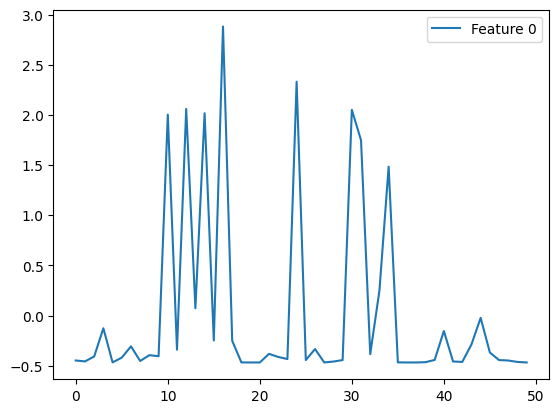

In [19]:
for i in range(X_train.shape[-1]):
    plt.plot(X_train[:T_max,0,vertex_idx,i].flatten(), label=f'Feature {i}')
    plt.legend()

# Training


===============HIDDEN_DIM: 16, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=4.068079e+00/val_loss=2.434872e+00/train_mae=1.514705e+00/val_mae=1.815284e+00/val_mape=7.688936e+02/val_r2=-3.793159e+00/val_r2_batch=-4.009718e+00/val_r2_d1=-3.793159e+00
epoch=2/200train_loss=2.853964e+00/val_loss=2.421361e+00/train_mae=1.863438e+00/val_mae=1.755482e+00/val_mape=7.401117e+02/val_r2=-3.490912e+00/val_r2_batch=-3.693460e+00/val_r2_d1=-3.490912e+00
epoch=3/200train_loss=2.821430e+00/val_loss=2.418843e+00/train_mae=1.842819e+00/val_mae=1.752184e+00/val_mape=7.400530e+02/val_r2=-3.478901e+00/val_r2_batch=-3.680798e+00/val_r2_d1=-3.478901e+00
epoch=4/200train_loss=2.826765e+00/val_loss=2.413393e+00/train_mae=1.846439e+00/val_mae=1.711873e+00/val_mape=7.226382e+02/val_r2=-3.293222e+00/val_r2_batch=-3.484460e+00/val_r2_d1=-3.293222e+00
epoch=5/200train_loss=2.820473e+00/val_loss=2.417621e+00/train_mae=1.83

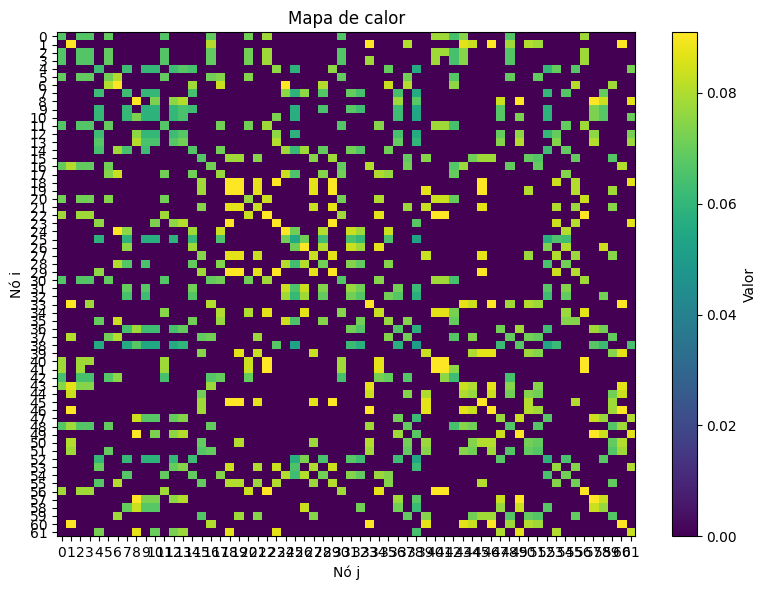

===============HIDDEN_DIM: 16, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=4.308501e+00/val_loss=2.859551e+00/train_mae=1.435861e+00/val_mae=2.331220e+00/val_mape=9.917987e+02/val_r2=-6.699863e+00/val_r2_batch=-7.081447e+00/val_r2_d1=-6.699863e+00
epoch=2/200train_loss=2.968363e+00/val_loss=2.438090e+00/train_mae=1.907925e+00/val_mae=1.791823e+00/val_mape=7.520414e+02/val_r2=-3.654709e+00/val_r2_batch=-3.866909e+00/val_r2_d1=-3.654709e+00
epoch=3/200train_loss=2.861970e+00/val_loss=2.431994e+00/train_mae=1.851225e+00/val_mae=1.818196e+00/val_mape=7.722957e+02/val_r2=-3.808116e+00/val_r2_batch=-4.026665e+00/val_r2_d1=-3.808116e+00
epoch=4/200train_loss=2.843243e+00/val_loss=2.443317e+00/train_mae=1.807283e+00/val_mae=1.857277e+00/val_mape=7.932635e+02/val_r2=-4.012480e+00/val_r2_batch=-4.241813e+00/val_r2_d1=-4.012480e+00
epoch=5/200train_loss=2.851818e+00/val_loss=2.477762e+00/train_mae=1.84

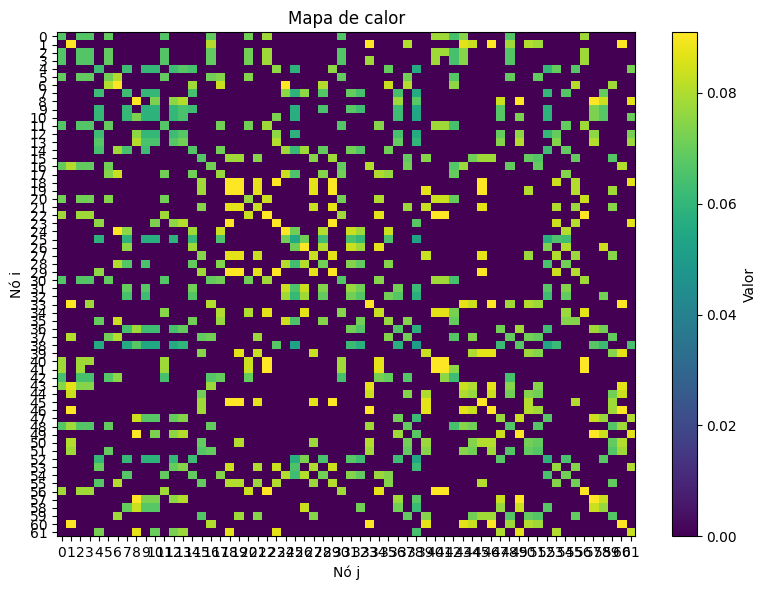

===============HIDDEN_DIM: 16, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.2===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=4.256209e+00/val_loss=2.544413e+00/train_mae=1.426484e+00/val_mae=1.903607e+00/val_mape=7.902028e+02/val_r2=-4.206546e+00/val_r2_batch=-4.458197e+00/val_r2_d1=-4.206546e+00
epoch=2/200train_loss=2.954597e+00/val_loss=2.508228e+00/train_mae=1.844158e+00/val_mae=1.973514e+00/val_mape=8.381386e+02/val_r2=-4.602232e+00/val_r2_batch=-4.864020e+00/val_r2_d1=-4.602232e+00
epoch=3/200train_loss=2.894320e+00/val_loss=2.439724e+00/train_mae=1.872561e+00/val_mae=1.830903e+00/val_mape=7.759854e+02/val_r2=-3.867058e+00/val_r2_batch=-4.088335e+00/val_r2_d1=-3.867058e+00
epoch=4/200train_loss=2.855004e+00/val_loss=2.448328e+00/train_mae=1.835951e+00/val_mae=1.868736e+00/val_mape=7.938275e+02/val_r2=-4.053868e+00/val_r2_batch=-4.286424e+00/val_r2_d1=-4.053868e+00
epoch=5/200train_loss=2.854281e+00/val_loss=2.439078e+00/train_mae=1.84

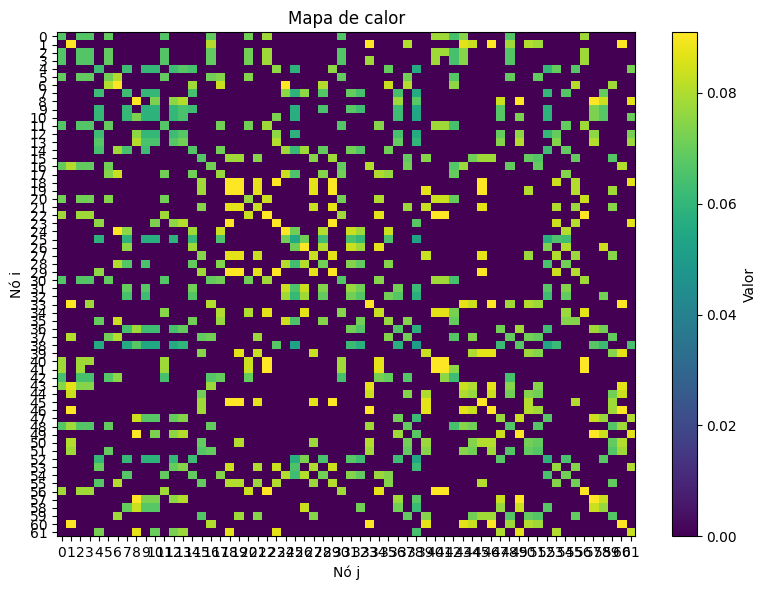

===============HIDDEN_DIM: 32, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=4.078323e+00/val_loss=2.508392e+00/train_mae=1.624180e+00/val_mae=1.969274e+00/val_mape=8.338275e+02/val_r2=-4.573673e+00/val_r2_batch=-4.835160e+00/val_r2_d1=-4.573673e+00
epoch=2/200train_loss=2.845053e+00/val_loss=2.427852e+00/train_mae=1.867301e+00/val_mae=1.762463e+00/val_mape=7.411061e+02/val_r2=-3.516467e+00/val_r2_batch=-3.721691e+00/val_r2_d1=-3.516467e+00
epoch=3/200train_loss=2.843362e+00/val_loss=2.449942e+00/train_mae=1.855434e+00/val_mae=1.848634e+00/val_mape=7.886915e+02/val_r2=-3.977080e+00/val_r2_batch=-4.202662e+00/val_r2_d1=-3.977080e+00
epoch=4/200train_loss=2.829244e+00/val_loss=2.423313e+00/train_mae=1.837899e+00/val_mae=1.775048e+00/val_mape=7.548080e+02/val_r2=-3.610081e+00/val_r2_batch=-3.815957e+00/val_r2_d1=-3.610081e+00
epoch=5/200train_loss=2.850934e+00/val_loss=2.514799e+00/train_mae=1.84

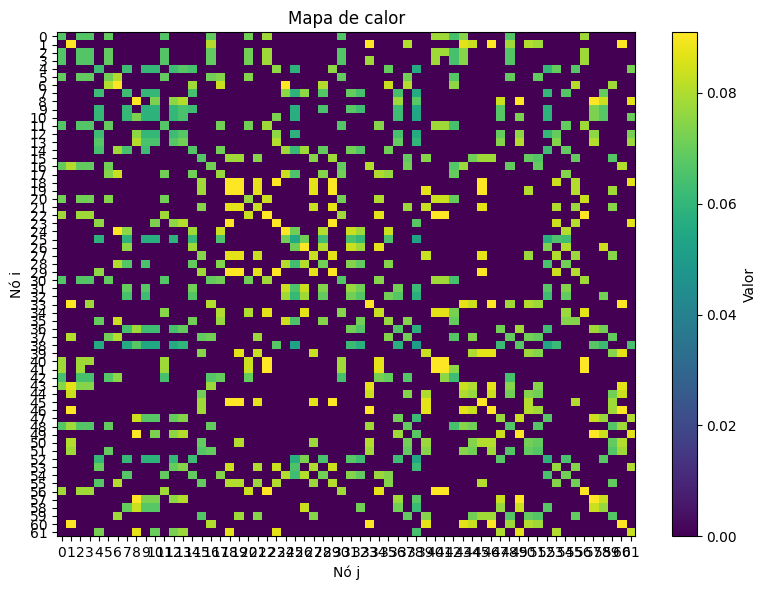

===============HIDDEN_DIM: 32, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.736391e+00/val_loss=2.433335e+00/train_mae=1.628323e+00/val_mae=1.781884e+00/val_mape=7.506507e+02/val_r2=-3.620968e+00/val_r2_batch=-3.828891e+00/val_r2_d1=-3.620968e+00
epoch=2/200train_loss=2.842988e+00/val_loss=2.472353e+00/train_mae=1.824819e+00/val_mae=1.910671e+00/val_mape=8.169268e+02/val_r2=-4.283685e+00/val_r2_batch=-4.529788e+00/val_r2_d1=-4.283685e+00
epoch=3/200train_loss=2.839541e+00/val_loss=2.425568e+00/train_mae=1.842910e+00/val_mae=1.810230e+00/val_mape=7.708151e+02/val_r2=-3.770070e+00/val_r2_batch=-3.987867e+00/val_r2_d1=-3.770070e+00
epoch=4/200train_loss=2.830434e+00/val_loss=2.451463e+00/train_mae=1.821753e+00/val_mae=1.885420e+00/val_mape=8.019915e+02/val_r2=-4.129972e+00/val_r2_batch=-4.371400e+00/val_r2_d1=-4.129972e+00
epoch=5/200train_loss=2.830276e+00/val_loss=2.414818e+00/train_mae=1.80

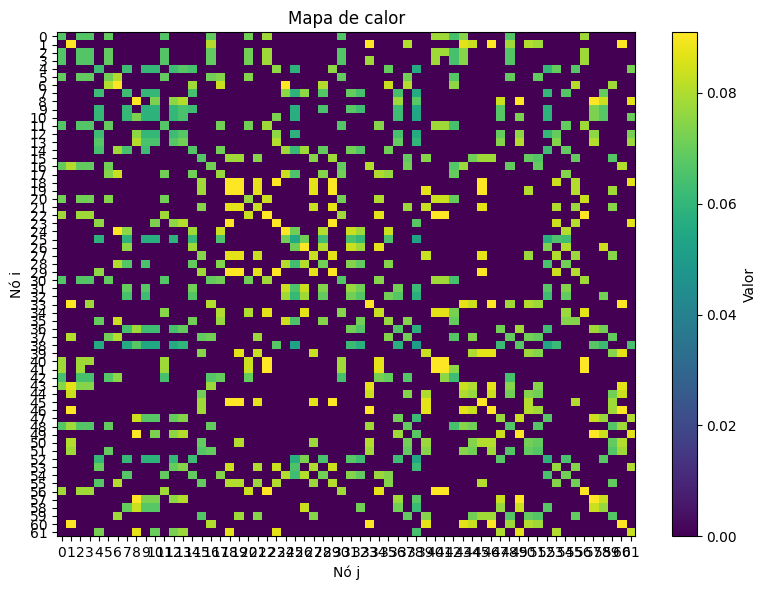

===============HIDDEN_DIM: 32, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.2===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=4.304916e+00/val_loss=2.437065e+00/train_mae=1.540590e+00/val_mae=1.792904e+00/val_mape=7.577182e+02/val_r2=-3.690627e+00/val_r2_batch=-3.898849e+00/val_r2_d1=-3.690627e+00
epoch=2/200train_loss=2.878226e+00/val_loss=2.417185e+00/train_mae=1.820852e+00/val_mae=1.714312e+00/val_mape=7.223937e+02/val_r2=-3.300390e+00/val_r2_batch=-3.492863e+00/val_r2_d1=-3.300390e+00
epoch=3/200train_loss=2.870734e+00/val_loss=2.465310e+00/train_mae=1.842369e+00/val_mae=1.901017e+00/val_mape=8.105826e+02/val_r2=-4.226969e+00/val_r2_batch=-4.470124e+00/val_r2_d1=-4.226969e+00
epoch=4/200train_loss=2.840293e+00/val_loss=2.508336e+00/train_mae=1.813116e+00/val_mae=1.971813e+00/val_mape=8.459719e+02/val_r2=-4.609790e+00/val_r2_batch=-4.874217e+00/val_r2_d1=-4.609790e+00
epoch=5/200train_loss=2.839499e+00/val_loss=2.483380e+00/train_mae=1.82

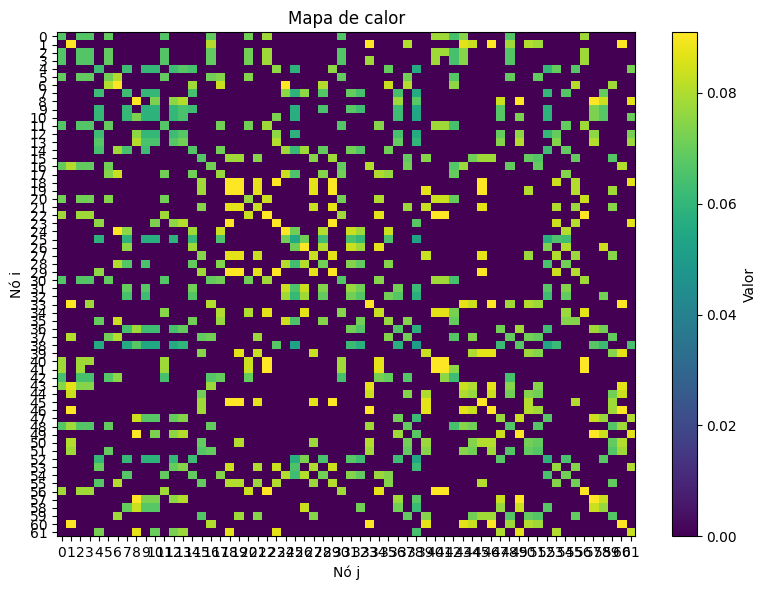

===============HIDDEN_DIM: 64, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.596835e+00/val_loss=2.461252e+00/train_mae=1.663724e+00/val_mae=1.874011e+00/val_mape=7.901612e+02/val_r2=-4.064801e+00/val_r2_batch=-4.301372e+00/val_r2_d1=-4.064801e+00
epoch=2/200train_loss=2.854327e+00/val_loss=2.512962e+00/train_mae=1.866402e+00/val_mae=1.982927e+00/val_mape=8.489136e+02/val_r2=-4.659338e+00/val_r2_batch=-4.928317e+00/val_r2_d1=-4.659338e+00
epoch=3/200train_loss=2.800648e+00/val_loss=2.405588e+00/train_mae=1.833806e+00/val_mae=1.707609e+00/val_mape=7.260077e+02/val_r2=-3.290139e+00/val_r2_batch=-3.480289e+00/val_r2_d1=-3.290139e+00
epoch=4/200train_loss=2.842170e+00/val_loss=2.467458e+00/train_mae=1.803722e+00/val_mae=1.920261e+00/val_mape=8.209532e+02/val_r2=-4.322411e+00/val_r2_batch=-4.571698e+00/val_r2_d1=-4.322411e+00
epoch=5/200train_loss=2.810960e+00/val_loss=2.426095e+00/train_mae=1.82

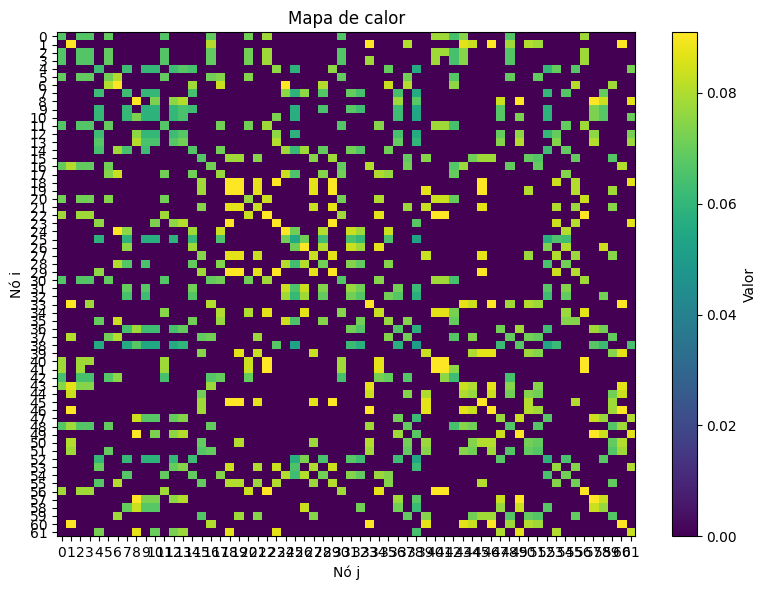

===============HIDDEN_DIM: 64, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.492082e+00/val_loss=2.455111e+00/train_mae=1.633604e+00/val_mae=1.850890e+00/val_mape=7.784545e+02/val_r2=-3.940831e+00/val_r2_batch=-4.171406e+00/val_r2_d1=-3.940831e+00
epoch=2/200train_loss=2.855258e+00/val_loss=2.451332e+00/train_mae=1.840821e+00/val_mae=1.850137e+00/val_mape=7.930526e+02/val_r2=-3.995618e+00/val_r2_batch=-4.223204e+00/val_r2_d1=-3.995618e+00
epoch=3/200train_loss=2.839072e+00/val_loss=2.456091e+00/train_mae=1.839838e+00/val_mae=1.860123e+00/val_mape=7.991313e+02/val_r2=-4.054585e+00/val_r2_batch=-4.283029e+00/val_r2_d1=-4.054585e+00
epoch=4/200train_loss=2.870410e+00/val_loss=2.444934e+00/train_mae=1.791734e+00/val_mae=1.847522e+00/val_mape=7.939678e+02/val_r2=-3.984591e+00/val_r2_batch=-4.211824e+00/val_r2_d1=-3.984591e+00
epoch=5/200train_loss=2.811081e+00/val_loss=2.404159e+00/train_mae=1.82

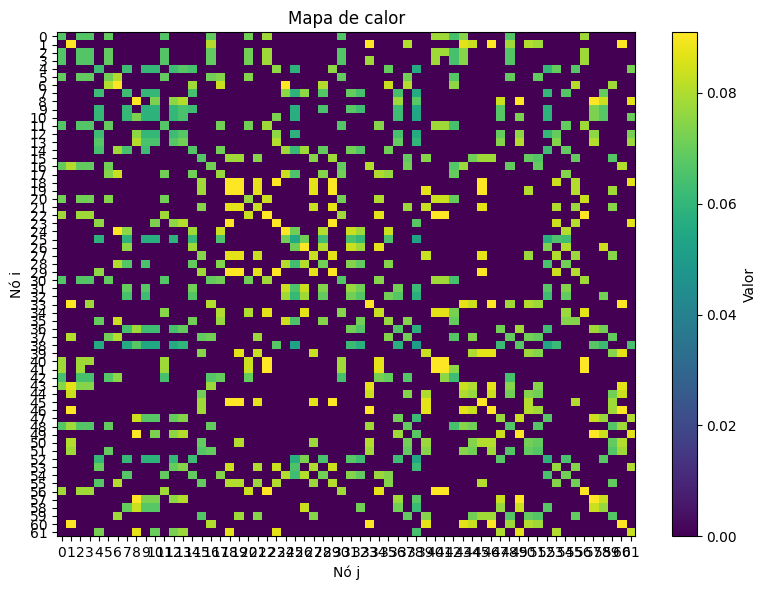

===============HIDDEN_DIM: 64, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.2===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.724024e+00/val_loss=2.504098e+00/train_mae=1.685309e+00/val_mae=1.965026e+00/val_mape=8.337344e+02/val_r2=-4.549020e+00/val_r2_batch=-4.812291e+00/val_r2_d1=-4.549020e+00
epoch=2/200train_loss=2.880831e+00/val_loss=2.410808e+00/train_mae=1.838282e+00/val_mae=1.678486e+00/val_mape=7.062773e+02/val_r2=-3.132615e+00/val_r2_batch=-3.315198e+00/val_r2_d1=-3.132615e+00
epoch=3/200train_loss=2.843557e+00/val_loss=2.553521e+00/train_mae=1.820052e+00/val_mae=2.034586e+00/val_mape=8.741176e+02/val_r2=-4.954628e+00/val_r2_batch=-5.235847e+00/val_r2_d1=-4.954628e+00
epoch=4/200train_loss=2.822164e+00/val_loss=2.459341e+00/train_mae=1.828854e+00/val_mae=1.843085e+00/val_mape=7.945592e+02/val_r2=-3.990725e+00/val_r2_batch=-4.214219e+00/val_r2_d1=-3.990725e+00
epoch=5/200train_loss=2.831767e+00/val_loss=2.434175e+00/train_mae=1.82

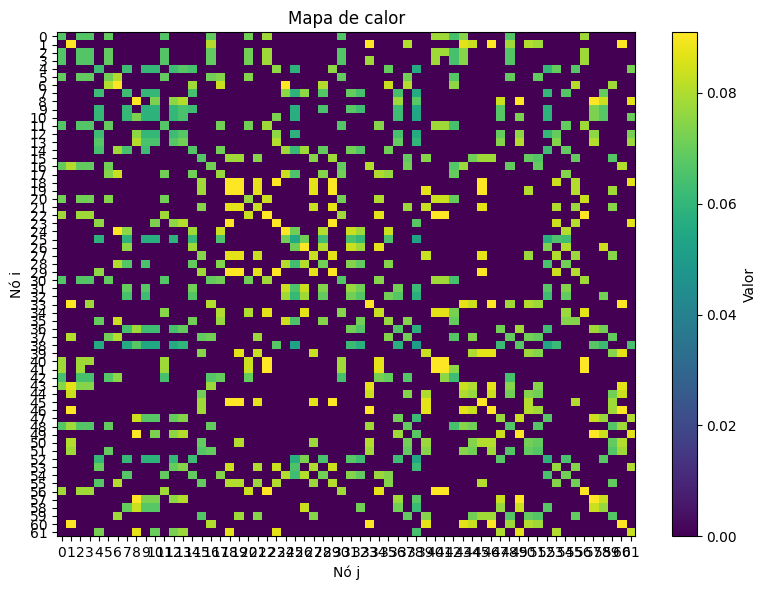

===============HIDDEN_DIM: 128, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.363349e+00/val_loss=2.443905e+00/train_mae=1.700422e+00/val_mae=1.855423e+00/val_mape=7.912607e+02/val_r2=-3.997391e+00/val_r2_batch=-4.227012e+00/val_r2_d1=-3.997391e+00
epoch=2/200train_loss=2.904953e+00/val_loss=2.465762e+00/train_mae=1.857468e+00/val_mae=1.910229e+00/val_mape=8.156371e+02/val_r2=-4.279123e+00/val_r2_batch=-4.521834e+00/val_r2_d1=-4.279123e+00
epoch=3/200train_loss=2.840806e+00/val_loss=2.572800e+00/train_mae=1.836694e+00/val_mae=2.037138e+00/val_mape=8.794425e+02/val_r2=-4.998408e+00/val_r2_batch=-5.276329e+00/val_r2_d1=-4.998408e+00
epoch=4/200train_loss=2.831547e+00/val_loss=2.481421e+00/train_mae=1.821545e+00/val_mae=1.941494e+00/val_mape=8.311388e+02/val_r2=-4.439454e+00/val_r2_batch=-4.694614e+00/val_r2_d1=-4.439454e+00
epoch=5/200train_loss=2.829106e+00/val_loss=2.538062e+00/train_mae=1.8

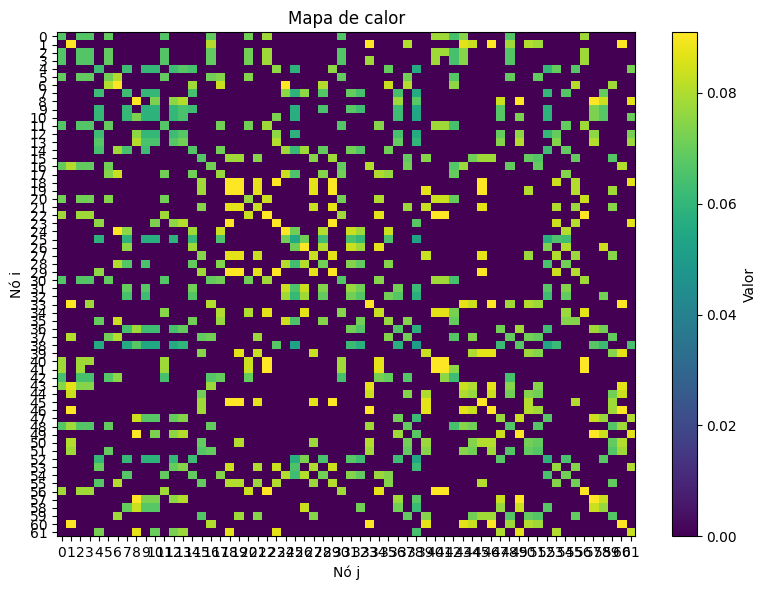

===============HIDDEN_DIM: 128, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=3.413790e+00/val_loss=2.738467e+00/train_mae=1.638488e+00/val_mae=2.201768e+00/val_mape=9.529064e+02/val_r2=-5.940737e+00/val_r2_batch=-6.273566e+00/val_r2_d1=-5.940737e+00
epoch=2/200train_loss=2.829945e+00/val_loss=2.698624e+00/train_mae=1.837302e+00/val_mae=2.139351e+00/val_mape=9.280928e+02/val_r2=-5.599279e+00/val_r2_batch=-5.911821e+00/val_r2_d1=-5.599279e+00
epoch=3/200train_loss=2.877372e+00/val_loss=2.477369e+00/train_mae=1.848798e+00/val_mae=1.933100e+00/val_mape=8.254241e+02/val_r2=-4.395367e+00/val_r2_batch=-4.644808e+00/val_r2_d1=-4.395367e+00
epoch=4/200train_loss=2.860571e+00/val_loss=2.473322e+00/train_mae=1.865780e+00/val_mae=1.896011e+00/val_mape=8.128466e+02/val_r2=-4.229513e+00/val_r2_batch=-4.467817e+00/val_r2_d1=-4.229513e+00
epoch=5/200train_loss=2.821134e+00/val_loss=2.445414e+00/train_mae=1.8

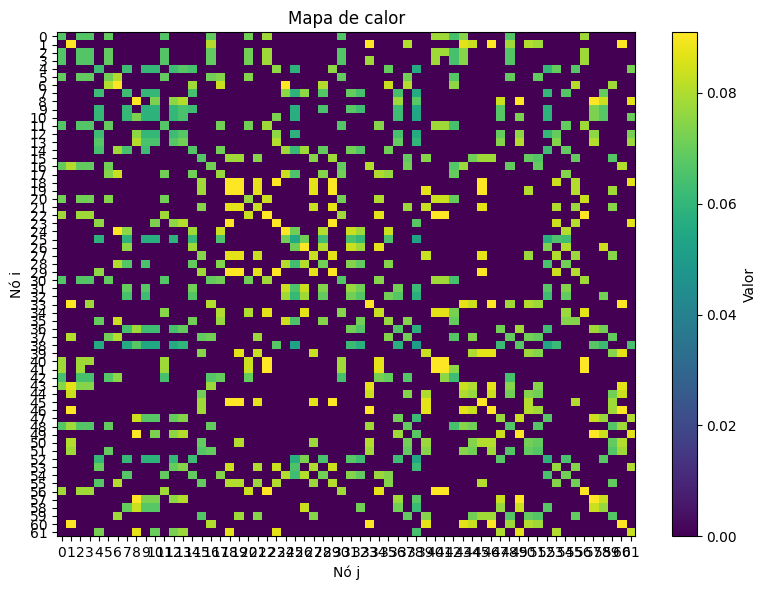

===============HIDDEN_DIM: 128, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.2===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=5.606653e+00/val_loss=2.449397e+00/train_mae=2.383927e+00/val_mae=1.771008e+00/val_mape=7.392546e+02/val_r2=-3.535898e+00/val_r2_batch=-3.748502e+00/val_r2_d1=-3.535898e+00
epoch=2/200train_loss=2.866545e+00/val_loss=2.443496e+00/train_mae=1.843600e+00/val_mae=1.532860e+00/val_mape=6.360783e+02/val_r2=-2.483755e+00/val_r2_batch=-2.633114e+00/val_r2_d1=-2.483755e+00
epoch=3/200train_loss=2.859694e+00/val_loss=2.413021e+00/train_mae=1.825405e+00/val_mae=1.612788e+00/val_mape=6.790677e+02/val_r2=-2.852070e+00/val_r2_batch=-3.019861e+00/val_r2_d1=-2.852070e+00
epoch=4/200train_loss=2.846591e+00/val_loss=2.475934e+00/train_mae=1.813855e+00/val_mae=1.892124e+00/val_mape=8.153035e+02/val_r2=-4.229858e+00/val_r2_batch=-4.466866e+00/val_r2_d1=-4.229858e+00
epoch=5/200train_loss=2.829632e+00/val_loss=2.404289e+00/train_mae=1.8

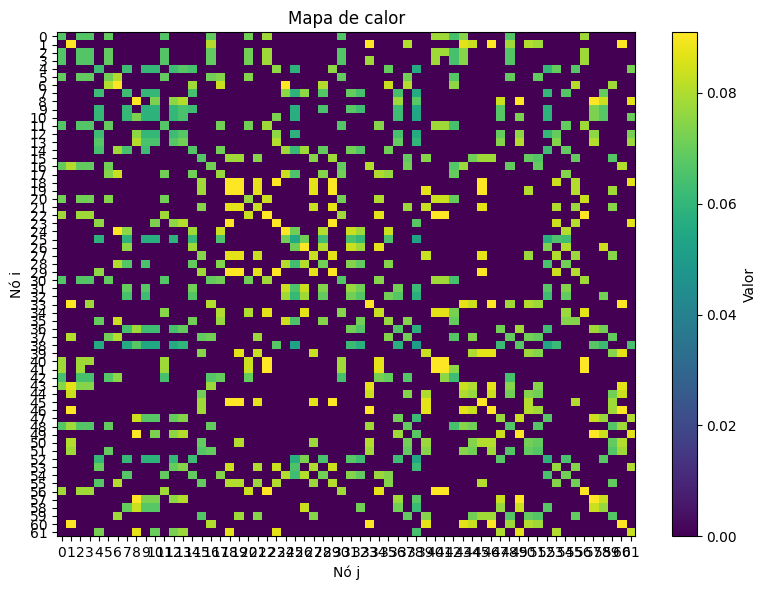

===============HIDDEN_DIM: 256, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=1.182153e+01/val_loss=2.475306e+00/train_mae=3.114332e+00/val_mae=1.921743e+00/val_mape=8.203766e+02/val_r2=-4.350669e+00/val_r2_batch=-4.592925e+00/val_r2_d1=-4.350669e+00
epoch=2/200train_loss=2.845007e+00/val_loss=2.419594e+00/train_mae=1.828352e+00/val_mae=1.796502e+00/val_mape=7.637077e+02/val_r2=-3.708776e+00/val_r2_batch=-3.919217e+00/val_r2_d1=-3.708776e+00
epoch=3/200train_loss=2.854183e+00/val_loss=2.544379e+00/train_mae=1.828583e+00/val_mae=2.035822e+00/val_mape=8.679943e+02/val_r2=-4.932710e+00/val_r2_batch=-5.217713e+00/val_r2_d1=-4.932710e+00
epoch=4/200train_loss=2.837338e+00/val_loss=2.450575e+00/train_mae=1.844437e+00/val_mae=1.877410e+00/val_mape=7.982692e+02/val_r2=-4.099394e+00/val_r2_batch=-4.334985e+00/val_r2_d1=-4.099394e+00
epoch=5/200train_loss=2.835244e+00/val_loss=2.408380e+00/train_mae=1.8

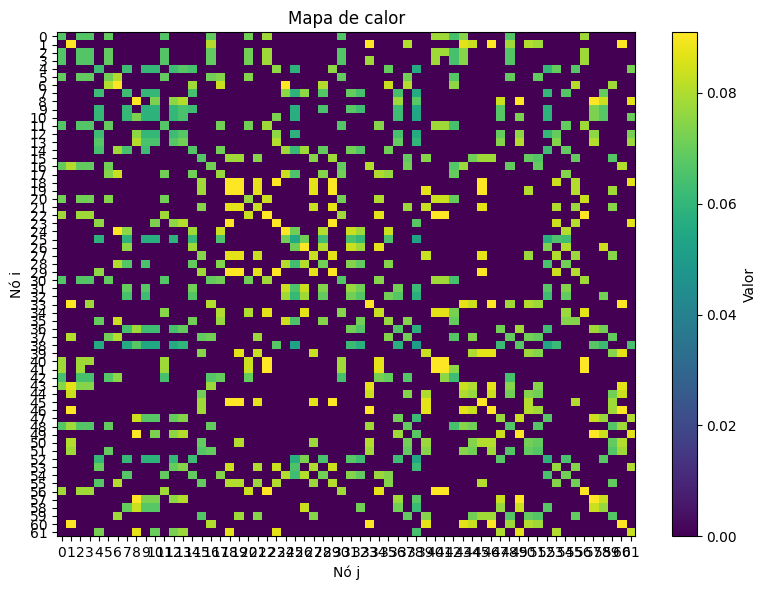

===============HIDDEN_DIM: 256, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=2.267582e+01/val_loss=2.509173e+00/train_mae=4.038054e+00/val_mae=1.958557e+00/val_mape=8.448508e+02/val_r2=-4.565141e+00/val_r2_batch=-4.821714e+00/val_r2_d1=-4.565141e+00
epoch=2/200train_loss=2.856869e+00/val_loss=2.467652e+00/train_mae=1.825197e+00/val_mae=1.917077e+00/val_mape=8.174156e+02/val_r2=-4.316245e+00/val_r2_batch=-4.559143e+00/val_r2_d1=-4.316245e+00
epoch=3/200train_loss=2.849277e+00/val_loss=2.437011e+00/train_mae=1.837364e+00/val_mae=1.806409e+00/val_mape=7.602255e+02/val_r2=-3.714809e+00/val_r2_batch=-3.936493e+00/val_r2_d1=-3.714809e+00
epoch=4/200train_loss=2.892785e+00/val_loss=2.437639e+00/train_mae=1.810381e+00/val_mae=1.814834e+00/val_mape=7.638176e+02/val_r2=-3.759394e+00/val_r2_batch=-3.980573e+00/val_r2_d1=-3.759394e+00
epoch=5/200train_loss=2.842858e+00/val_loss=2.417392e+00/train_mae=1.8

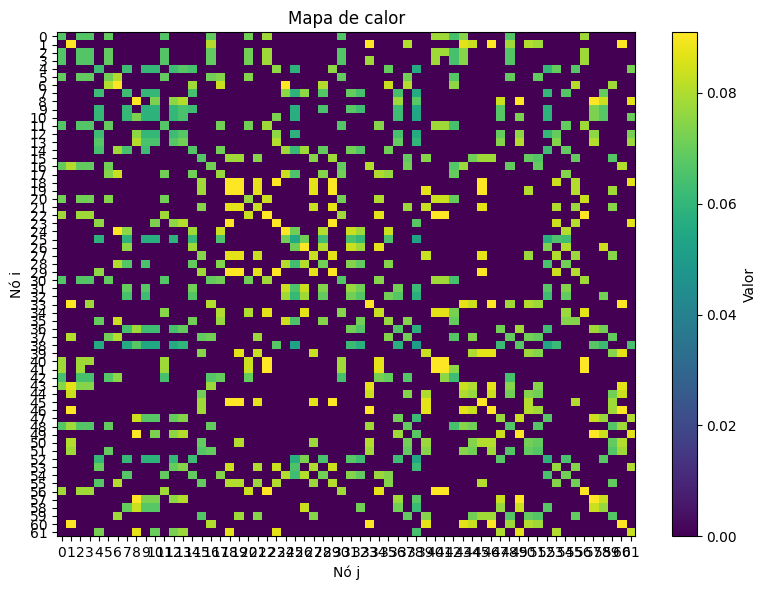

===============HIDDEN_DIM: 256, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.2===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=1.365426e+01/val_loss=2.442312e+00/train_mae=3.294755e+00/val_mae=1.776687e+00/val_mape=7.433171e+02/val_r2=-3.564572e+00/val_r2_batch=-3.776705e+00/val_r2_d1=-3.564572e+00
epoch=2/200train_loss=2.884519e+00/val_loss=2.442406e+00/train_mae=1.825227e+00/val_mae=1.836395e+00/val_mape=7.744602e+02/val_r2=-3.868750e+00/val_r2_batch=-4.096379e+00/val_r2_d1=-3.868750e+00
epoch=3/200train_loss=2.888337e+00/val_loss=2.463053e+00/train_mae=1.860682e+00/val_mae=1.899850e+00/val_mape=8.063940e+02/val_r2=-4.197964e+00/val_r2_batch=-4.445649e+00/val_r2_d1=-4.197964e+00
epoch=4/200train_loss=2.831735e+00/val_loss=2.424245e+00/train_mae=1.830109e+00/val_mae=1.580912e+00/val_mape=6.672109e+02/val_r2=-2.734984e+00/val_r2_batch=-2.895430e+00/val_r2_d1=-2.734984e+00
epoch=5/200train_loss=2.872828e+00/val_loss=2.440551e+00/train_mae=1.8

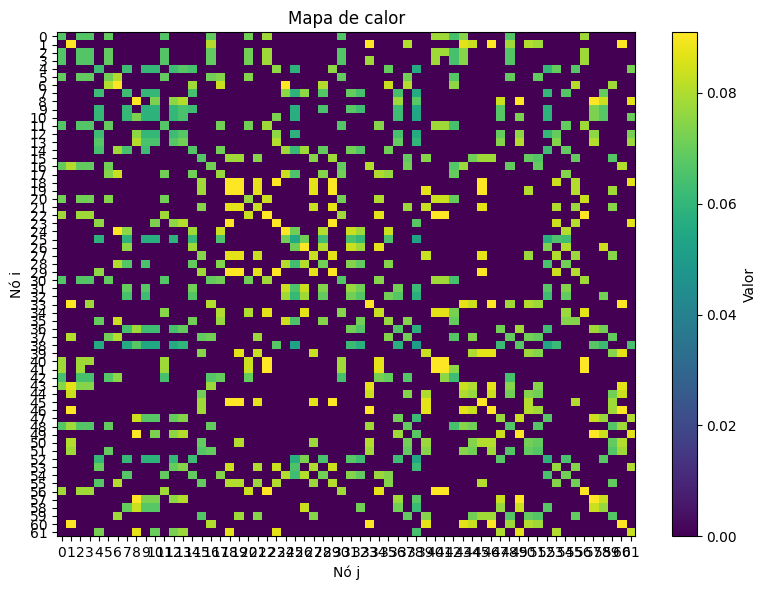

===============HIDDEN_DIM: 512, LR: 0.01, WEIGHT_DECAY: 0.005, DROPOUT: 0.0===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05
epoch=1/200train_loss=1.494023e+01/val_loss=2.548512e+00/train_mae=2.983953e+00/val_mae=1.957596e+00/val_mape=8.445490e+02/val_r2=-4.595325e+00/val_r2_batch=-4.848402e+00/val_r2_d1=-4.595325e+00
epoch=2/200train_loss=2.969611e+00/val_loss=2.420890e+00/train_mae=1.833969e+00/val_mae=1.632309e+00/val_mape=6.857430e+02/val_r2=-2.944167e+00/val_r2_batch=-3.112396e+00/val_r2_d1=-2.944167e+00
epoch=3/200train_loss=2.898750e+00/val_loss=2.500051e+00/train_mae=1.861705e+00/val_mae=1.946904e+00/val_mape=8.364791e+02/val_r2=-4.510529e+00/val_r2_batch=-4.758123e+00/val_r2_d1=-4.510529e+00
epoch=4/200train_loss=2.855077e+00/val_loss=2.554271e+00/train_mae=1.845295e+00/val_mae=1.998114e+00/val_mape=8.628818e+02/val_r2=-4.816027e+00/val_r2_batch=-5.074675e+00/val_r2_d1=-4.816027e+00
epoch=5/200train_loss=2.853750e+00/val_loss=2.430283e+00/train_mae=1.8

KeyboardInterrupt: 

In [20]:
lr_v                = [1e-2,1e-3]
weight_decay_v      = [5e-3,5e-4]
hidden_dim_v        = [16,32,64,128,256,512]
dropout_v           = [0.0,0.1,0.2]
delta_h             = 5.0


criterion          = make_weighted_mse_loss_standardized(y_train, extreme_quantile=0.9, extreme_weight=30.0, normalize_weights=True)

empty_graph         = torch.zeros((edge_index.shape))

combinations        = list(itertools.product(lr_v, weight_decay_v, hidden_dim_v, dropout_v))


for comb in combinations:
    print(f"===============HIDDEN_DIM: {comb[2]}, LR: {comb[0]}, WEIGHT_DECAY: {comb[1]}, DROPOUT: {comb[3]}===============")

    model = GLSTM_v2(N=N, edge_index=edge_index, in_channels=X_train.shape[-1], hidden_size=comb[2],
                            out_channels=horizon, lstm_layers=1, learn_adj=False, dropout=comb[3], cell_clip=None).to(device)

    model.apply(reset_weights)        
    window_folder = os.path.join("..", "Experiments", "date_06_05", "dataset_00_25", "ONLY_TP", f"WINDOW_{window_size}_HORIZON_{horizon}_DROP_{comb[3]}+WMSE_0.9_quantile_W_30_K_{K}")

    exp_path = create_next_experiment_folder(window_folder)
    
    model.apply(reset_weights)
    model, hist, summary = train_stable(
                model           = model, 
                train_loader    = train_loader, 
                val_loader      = val_loader, 
                hidden_dim      = comb[2], 
                window_size     = window_size,
                horizon         = horizon,   
                epochs          = 200, 
                lr              = comb[0], 
                weight_decay    = comb[1], 
                patience        = 35, 
                criterion       = criterion,
                run_dir         = os.path.join(exp_path),
                adj_lr_factor   = 0.05,
                use_amp         = True,
                debug_checks    = False,
                max_norm        = 2.0
            )
            
    model.eval()
    with torch.no_grad():
        pred                   = model(X_test.to(device)).detach().cpu()
        if z_score:
            pred_denormalized  = scaler_tp.inverse_transform(pred.reshape(-1,1)).reshape(pred.shape)
        if log_norm:
            pred_denormalized  = torch.expm1(pred_denormalized)
        y_test_denormalized    = torch.expm1(y_test) if log_norm else y_test
        

    daily_mean = torch.mean(y_test_denormalized[:T_max,0,:], dim=-1)

    plt.figure(figsize=(10,10))
    plt.axhline(y=y_test_denormalized.mean().item(), color='gray', linestyle='--', label='média histórica')
    plt.plot(daily_mean.reshape(-1,1), label='média diária')
    plt.xlim(0,daily_mean.shape[0])
    plt.plot(pred_denormalized[:T_max,0,vertex_idx].reshape(-1,1), label='previsão')
    plt.plot(y_test_denormalized[:T_max,0,vertex_idx].reshape(-1,1), label='real')
    plt.legend()
    plt.savefig(os.path.join(exp_path, "previsão.png"))
    plt.close()
    plot_heatmap_nn(model.cell_0.current_adjacency(), figsize=(8,6), savefig=os.path.join(exp_path, "adjacency_matrix.png"), close=True)
    plt.close()

torch.Size([15, 62, 1])


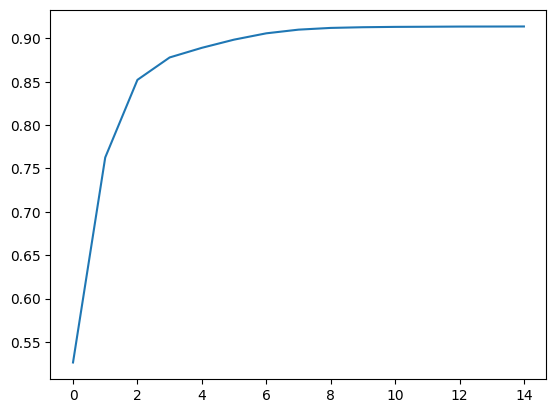

In [15]:
pred_T = forecast_autoregressive(
    model,
    X_test,
    T=15,
    target_col=0,
)
print(pred_T.shape)  # [15, N, 1]

plt.plot(pred_T[:,vertex_idx,0].reshape(-1,1))

# Post Train analysis


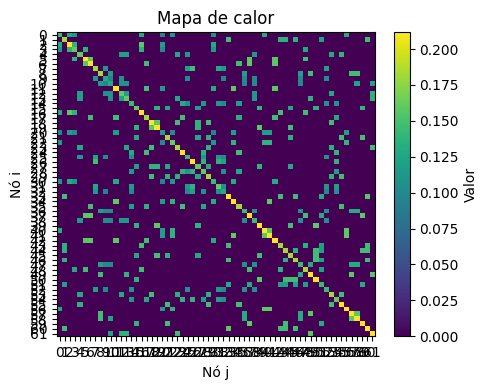

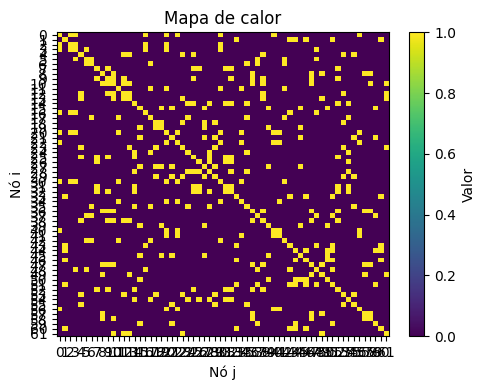

(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [28]:
plot_heatmap_nn(model.cell_0.current_adjacency(), figsize=(5,4))
plot_heatmap_nn(adjacency_matrix(N, edge_index), figsize=(5,4))

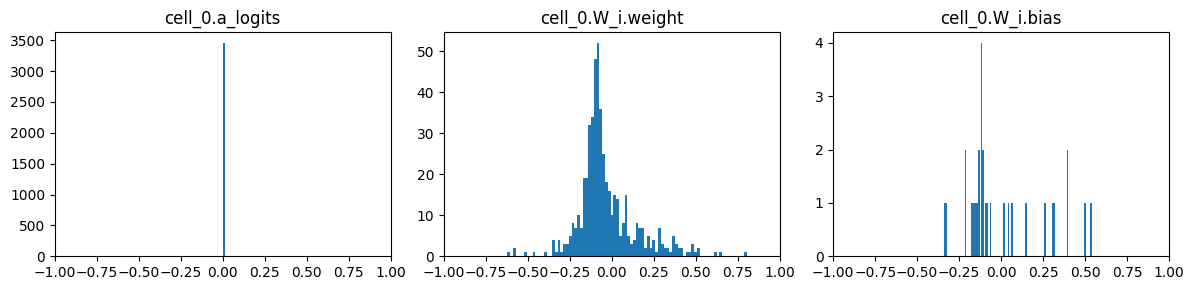

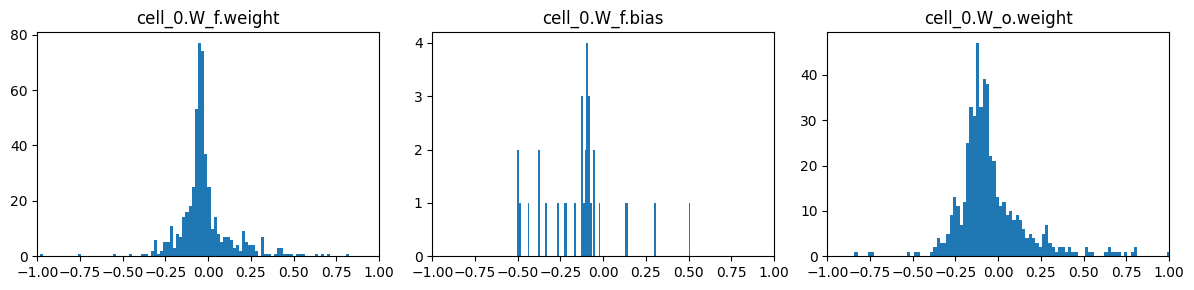

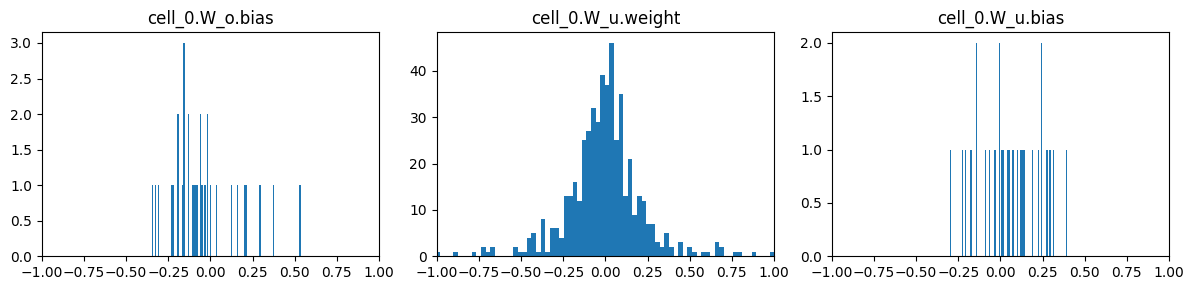

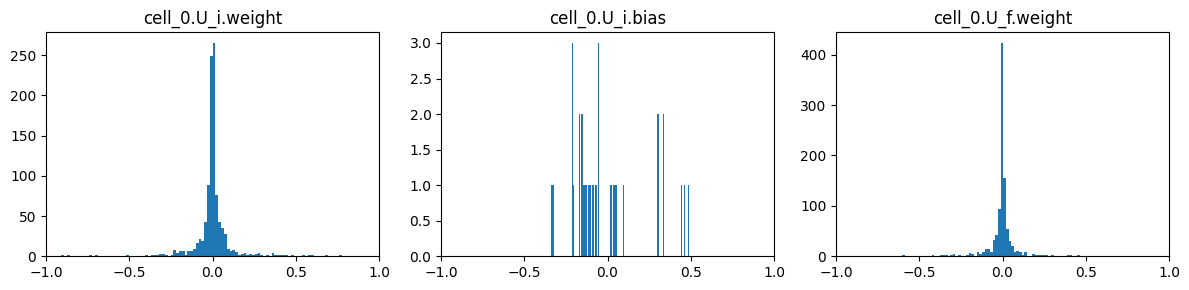

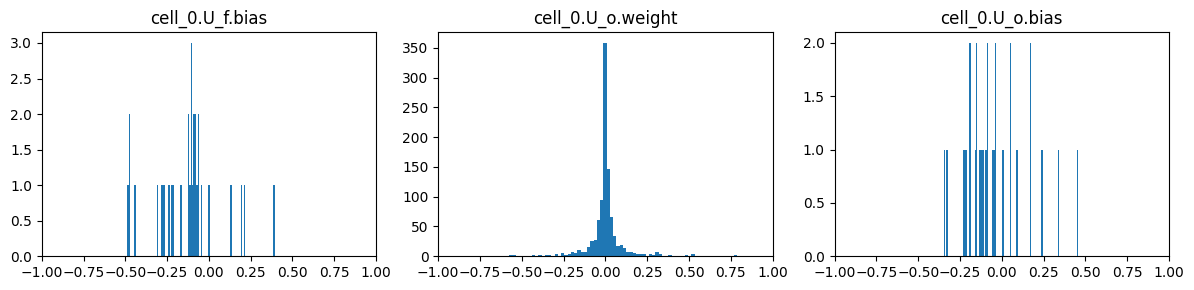

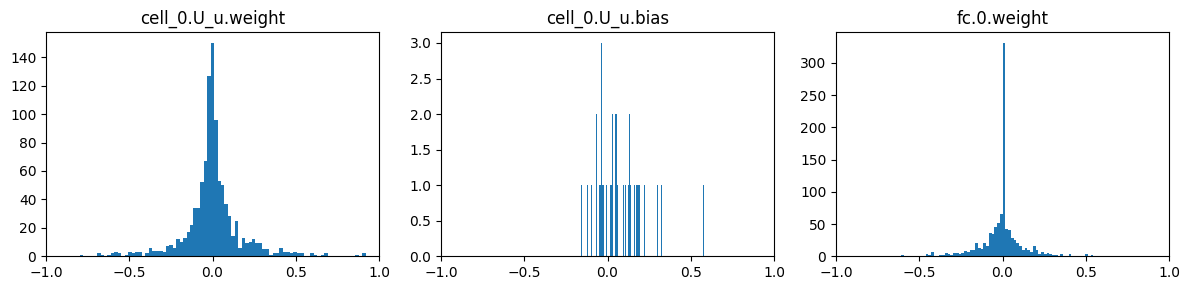

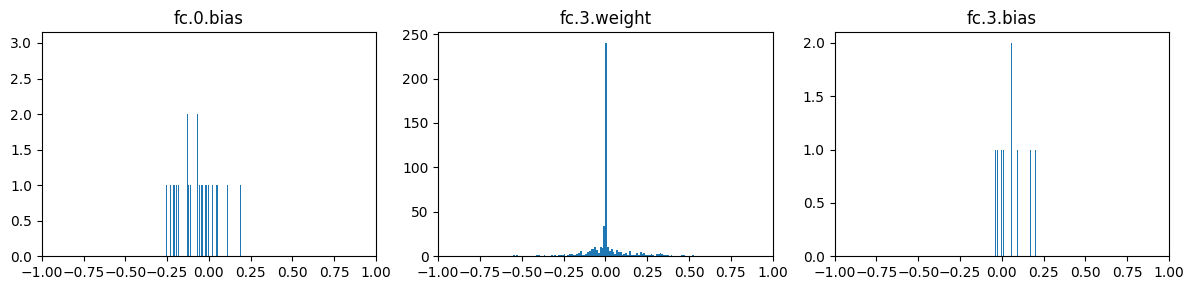

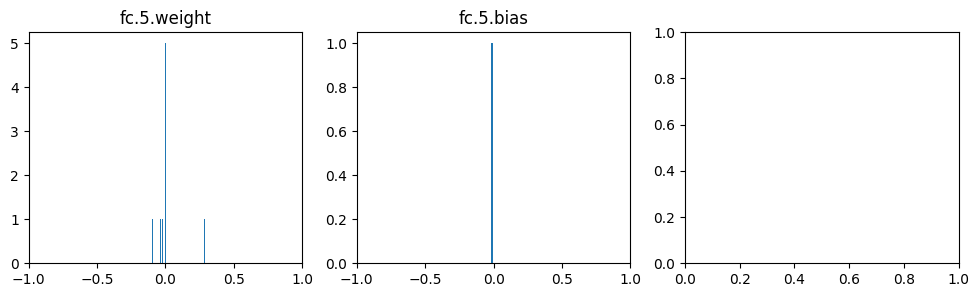

In [29]:
model_weights_hist(model)

In [13]:
import torch

def forecast_autoregressive(
    model,
    X_test,
    T,
    target_col=0,
    window_index=-1,
    future_exog=None,
    feedback_step=0,
    device=None,
):
    """
    Gera previsão autoregressiva de T passos à frente.

    Parameters
    ----------
    model : nn.Module
        Modelo que recebe [B, W, N, F] e retorna [B, H, N].
    X_test : torch.Tensor
        Pode ser [B, W, N, F] ou [W, N, F].
    T : int
        Número de passos/dias futuros.
    target_col : int
        Índice da feature alvo dentro de X.
    window_index : int
        Se X_test for 4D, escolhe qual janela usar.
    future_exog : torch.Tensor or None
        Features futuras conhecidas com shape [T, N, F].
        Se None, replica o último passo e substitui só a coluna alvo.
    feedback_step : int
        Se o modelo prever múltiplos passos por chamada, usa este passo
        para retroalimentação. Para rollout padrão, deixe 0.
    device : str | torch.device | None

    Returns
    -------
    torch.Tensor
        Tensor [T, N, 1] com as previsões na escala do modelo.
    """
    if device is None:
        device = next(model.parameters()).device

    X_test = torch.as_tensor(X_test, dtype=torch.float32)

    if X_test.ndim == 4:
        window = X_test[window_index].clone()   # [W, N, F]
    elif X_test.ndim == 3:
        window = X_test.clone()                 # [W, N, F]
    else:
        raise ValueError("X_test deve ter shape [B, W, N, F] ou [W, N, F].")

    if T < 1:
        raise ValueError("T deve ser >= 1.")

    if not (0 <= target_col < window.shape[-1]):
        raise ValueError(f"target_col={target_col} fora do intervalo para F={window.shape[-1]}.")

    if future_exog is not None:
        future_exog = torch.as_tensor(future_exog, dtype=window.dtype)
        if future_exog.shape != (T, window.shape[1], window.shape[2]):
            raise ValueError(
                f"future_exog deve ter shape {(T, window.shape[1], window.shape[2])}, "
                f"mas recebeu {tuple(future_exog.shape)}."
            )

    was_training = model.training
    model.eval()

    window = window.to(device)
    preds = []

    with torch.no_grad():
        for t in range(T):
            y_block = model(window.unsqueeze(0)).squeeze(0)  # [H, N]

            if y_block.ndim == 1:
                y_hat = y_block
            else:
                if not (0 <= feedback_step < y_block.shape[0]):
                    raise ValueError(
                        f"feedback_step={feedback_step} inválido para saída com horizon={y_block.shape[0]}."
                    )
                y_hat = y_block[feedback_step]  # [N]

            preds.append(y_hat.detach().cpu())

            if future_exog is None:
                next_step = window[-1].clone()
            else:
                next_step = future_exog[t].to(device).clone()

            next_step[:, target_col] = y_hat
            window = torch.cat([window[1:], next_step.unsqueeze(0)], dim=0)

    if was_training:
        model.train()

    return torch.stack(preds, dim=0).unsqueeze(-1)  # [T, N, 1]


# NEW STUFF



## CORRELATION TOPOLOGY FOR G




In [14]:
import numpy as np
import pandas as pd

def build_correlation_graph(X: np.ndarray, threshold: float = 0.5, ensure_connected: bool = True) -> np.ndarray:
    """
    Constrói matriz de adjacência baseada em correlação de Spearman
    entre séries temporais de precipitação.

    Args:
        X: tensor shape (dias, 62, 20)
        threshold: correlação mínima para criar aresta
        ensure_connected: garante que nós isolados tenham ao menos 1 aresta

    Returns:
        adj_matrix: np.ndarray shape (62, 62)
    """
    # Extrai precipitação: shape (dias, n_nos)
    precip = X[:, :, 0]  # (dias, 62)
    n_nos = precip.shape[1]

    # Correlação de Spearman entre todos os pares de estações
    # spearmanr retorna (correlação, pvalue) — pegamos só a matriz de corr
    from scipy.stats import spearmanr
    corr_matrix, _ = spearmanr(precip)  # (62, 62)
    corr_matrix = np.array(corr_matrix)

    # Aplica threshold
    adj_matrix = (corr_matrix >= threshold).astype(float)
    np.fill_diagonal(adj_matrix, 0)  # remove self-loops

    # Garante conectividade mínima
    if ensure_connected:
        degrees = adj_matrix.sum(axis=1)
        isolated = np.where(degrees == 0)[0]

        for node in isolated:
            # Conecta ao nó mais correlacionado (excluindo ele mesmo)
            corr_row = corr_matrix[node].copy()
            corr_row[node] = -999  # exclui self
            best = np.argmax(corr_row)
            adj_matrix[node, best] = 1
            adj_matrix[best, node] = 1  # mantém simetria

    return adj_matrix

Nós:          62
Arestas:      363
Grau médio:   11.71
Isolados:     0


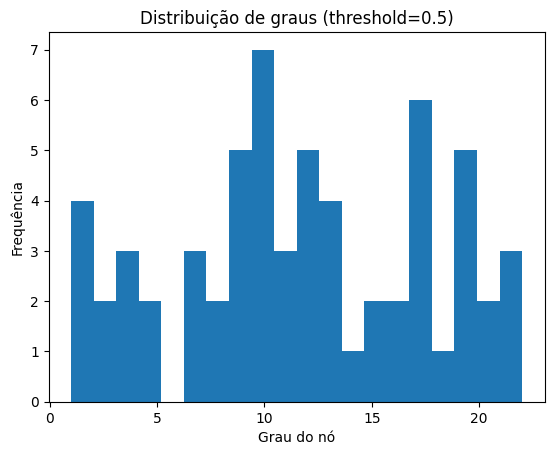

In [78]:
adj = build_correlation_graph(X, threshold=0.85)

# Diagnóstico rápido
n_nos = adj.shape[0]
n_arestas = int(adj.sum() / 2)
grau_medio = adj.sum(axis=1).mean()
isolados = (adj.sum(axis=1) == 0).sum()

print(f"Nós:          {n_nos}")
print(f"Arestas:      {n_arestas}")
print(f"Grau médio:   {grau_medio:.2f}")
print(f"Isolados:     {isolados}")

# Ver distribuição dos graus
import matplotlib.pyplot as plt
graus = adj.sum(axis=1)
plt.hist(graus, bins=20)
plt.xlabel("Grau do nó")
plt.ylabel("Frequência")
plt.title(f"Distribuição de graus (threshold={0.5})")
plt.show()

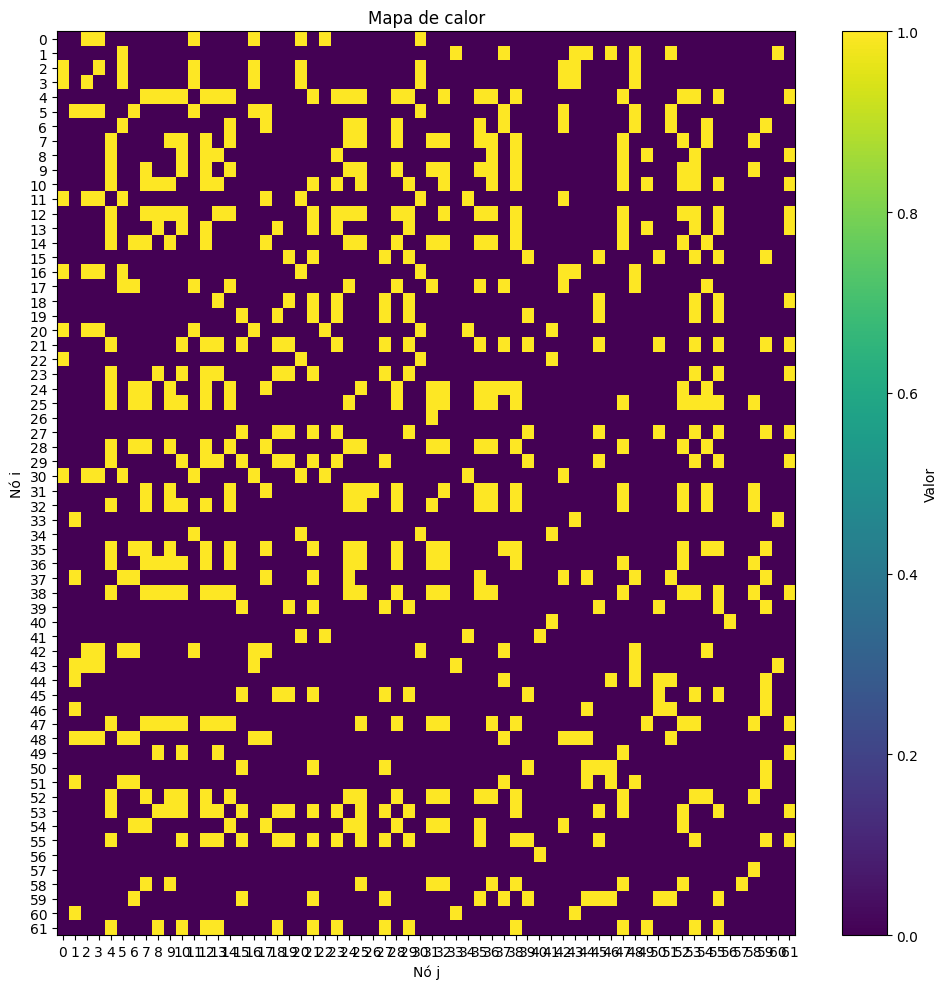

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [ ]:
plot_heatmap_nn(adj)

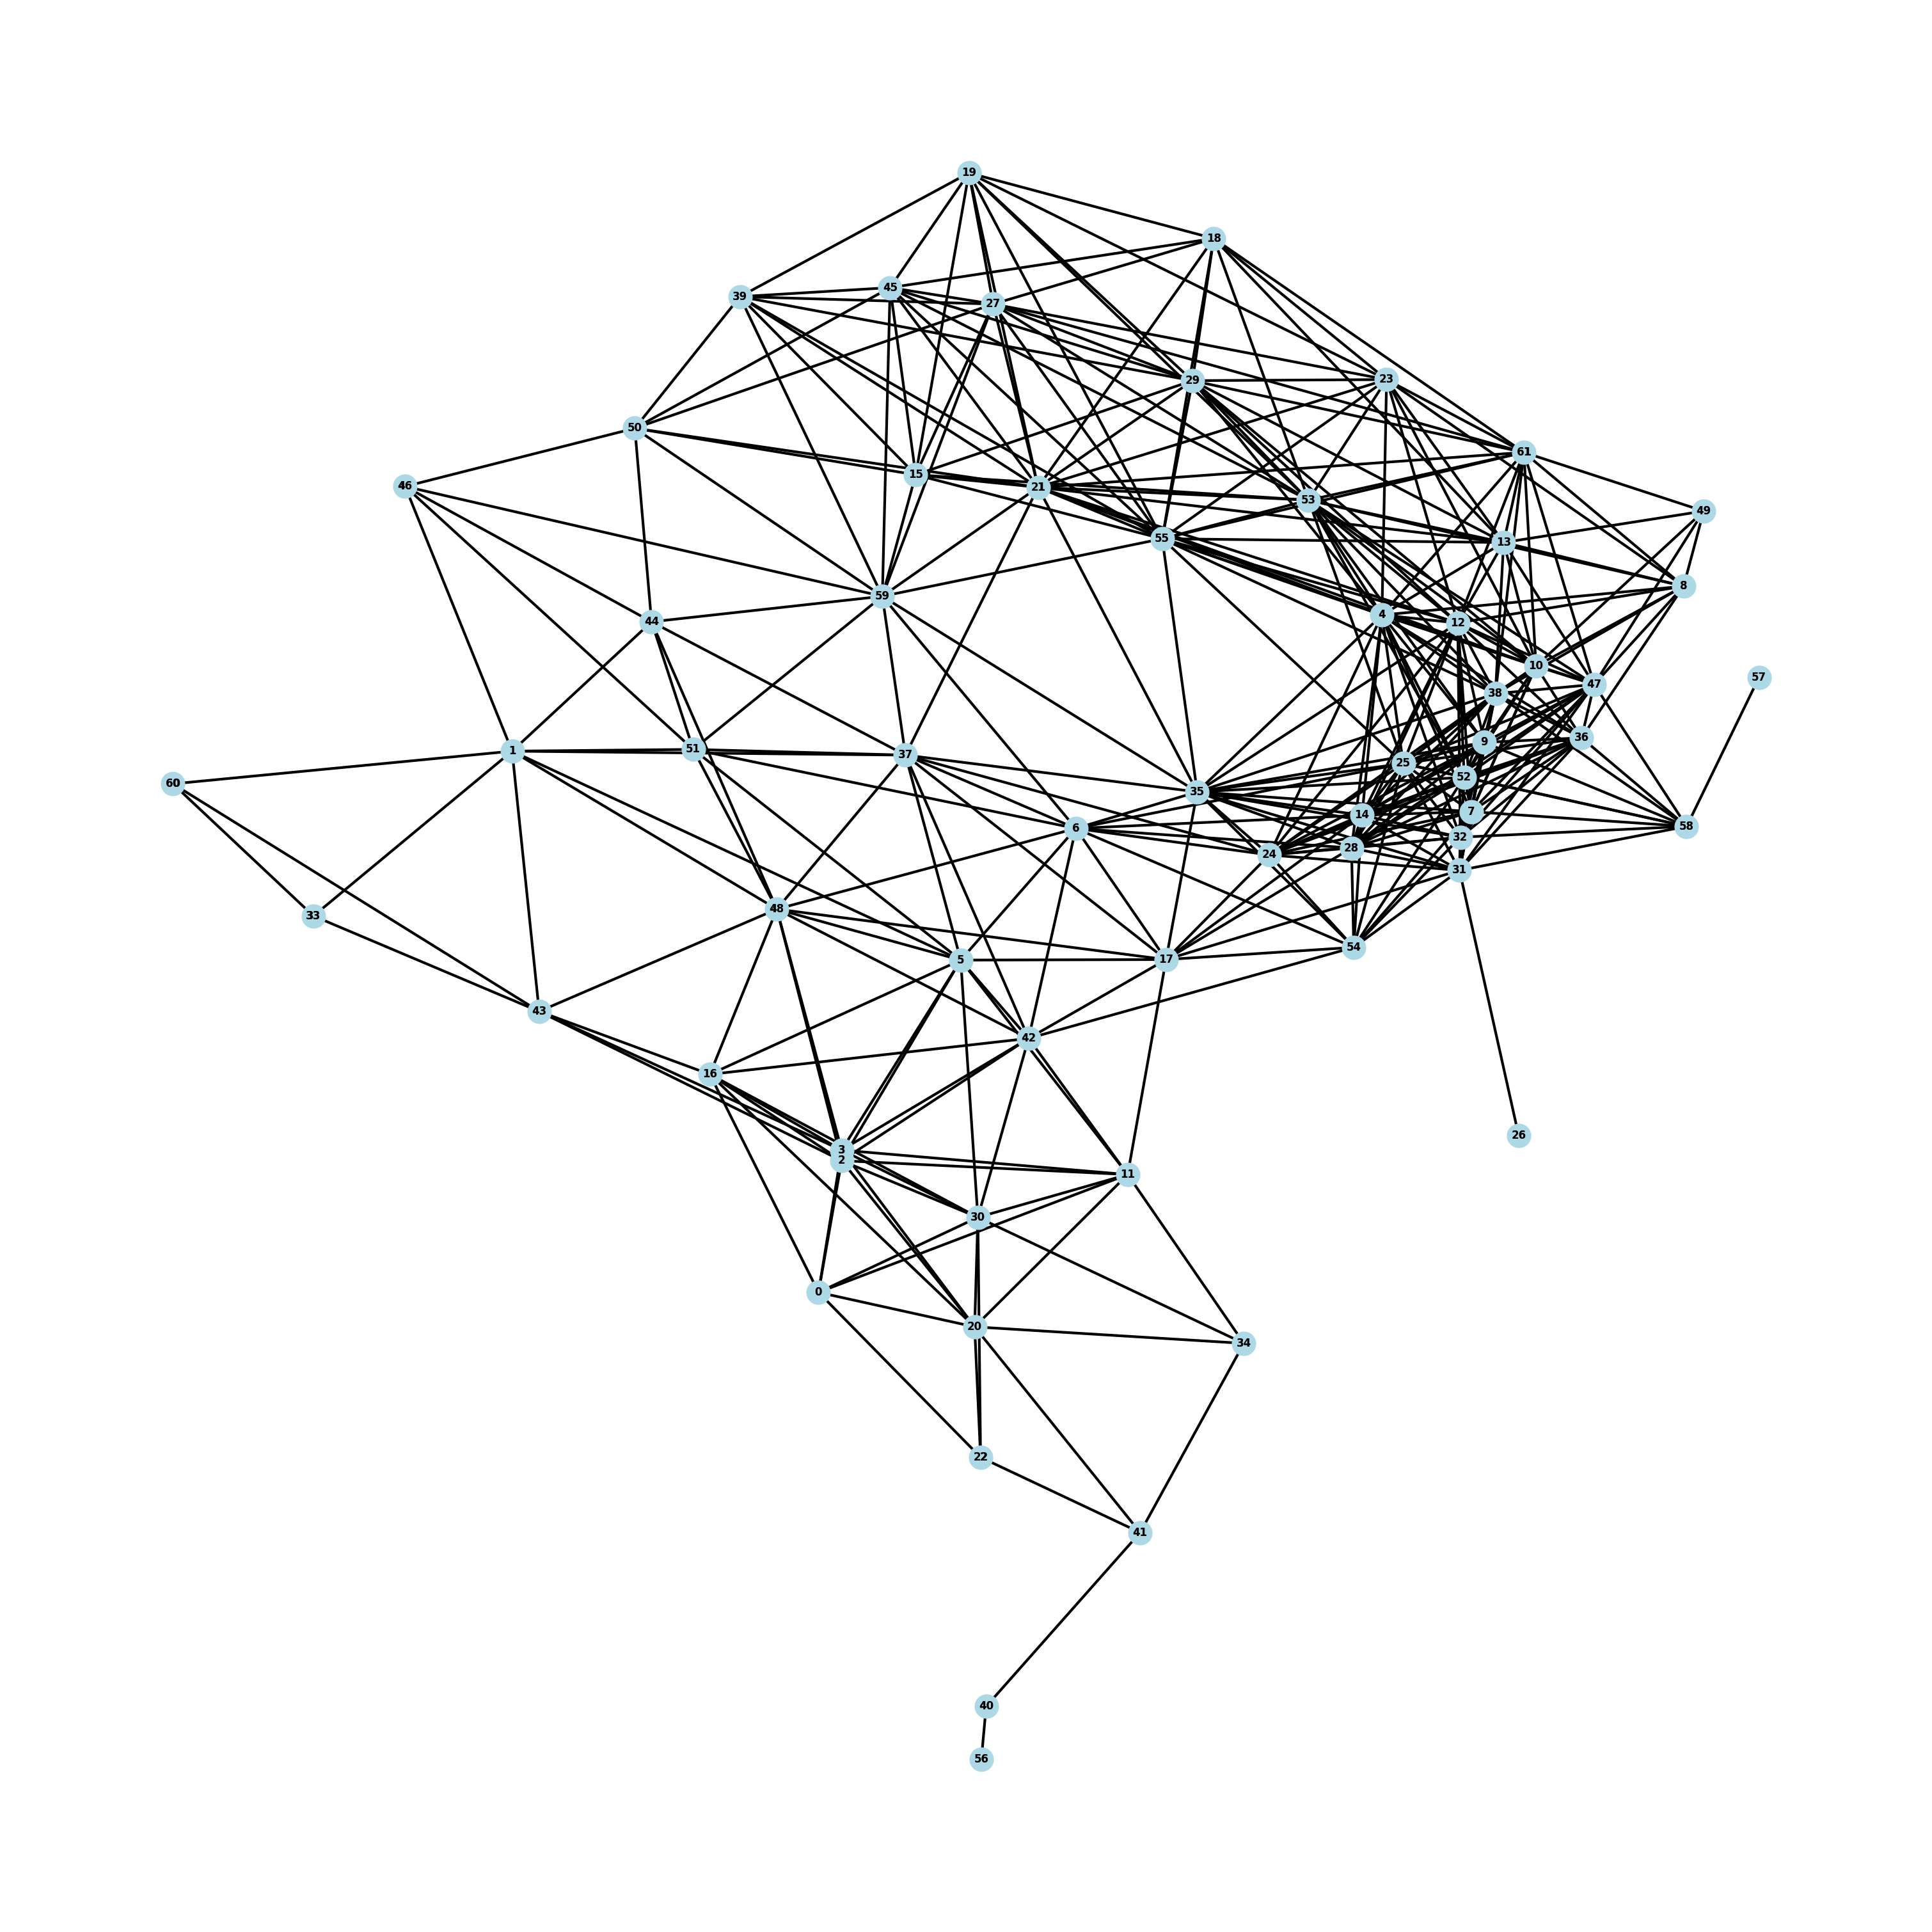

In [80]:
plot_graph(N, graph_matrix_index(torch.tensor(adj), threshold=0.5), pos)

## Weighted MSE Loss


In [19]:
def weighted_mse_loss_1(y_pred: torch.Tensor, y_true: torch.Tensor, 
                      threshold: float = 0.5, heavy_threshold: float = 15.0,
                      w_dry: float = 0.61, w_light: float = 1.0, w_heavy: float = 9546.28) -> torch.Tensor:
    """
    MSE ponderado por intensidade de precipitação.
    
    Pesos:
        - Dias secos  (precip < threshold)       → w_dry   (penaliza menos)
        - Chuva leve  (threshold <= precip < heavy_threshold) → w_light
        - Chuva forte (precip >= heavy_threshold) → w_heavy (penaliza mais)

    Args:
        y_pred:           predições do modelo
        y_true:           valores reais
        threshold:        limiar chuva/seco em mm (default 0.5mm)
        heavy_threshold:  limiar chuva forte em mm (default 15mm)
        w_dry:            peso dias secos
        w_light:          peso chuva leve
        w_heavy:          peso chuva forte

    Returns:
        loss escalar
    """
    # Máscara por categoria (baseada nos valores reais)
    dry   = (y_true <  threshold).float()
    light = ((y_true >= threshold) & (y_true < heavy_threshold)).float()
    heavy = (y_true >= heavy_threshold).float()

    # Mapa de pesos com mesma shape que y_true
    weights = w_dry * dry + w_light * light + w_heavy * heavy

    # MSE ponderado
    squared_error = (y_pred - y_true) ** 2
    loss = (weights * squared_error).mean()

    return loss

In [18]:
import numpy as np

def suggest_weights(precip: np.ndarray, 
                    threshold=0.5, 
                    heavy_threshold=15.0):
    """
    Sugere pesos inversamente proporcionais à frequência de cada classe.
    precip: array 1D com todos os valores de precipitação do treino
    """
    dry   = (precip <  threshold).sum() / precip.shape[0]
    light = ((precip >= threshold) & (precip < heavy_threshold)).sum() / precip.shape[0]
    heavy = (precip >= heavy_threshold).sum() / precip.shape[0]

    print(f"Dias secos:    {dry*100:.1f}%")
    print(f"Chuva leve:    {light*100:.1f}%")
    print(f"Chuva forte:   {heavy*100:.1f}%")

    # Peso inverso à frequência, normalizado para w_light = 1.0
    w_dry   = (1 / dry)   / (1 / light)
    w_heavy = (1 / heavy) / (1 / light)

    print(f"\nPesos sugeridos:")
    print(f"  w_dry   = {w_dry:.2f}")
    print(f"  w_light = 1.00")
    print(f"  w_heavy = {w_heavy:.2f}")

# Uso — precip de todos os nós e dias do treino
precip_train = X_train[..., 0].flatten()

suggest_weights(precip_train)

Dias secos:    84.6%
Chuva leve:    15.4%
Chuva forte:   0.0%

Pesos sugeridos:
  w_dry   = 0.18
  w_light = 1.00
  w_heavy = 9546.28
